# Environment and OpenCV Demo

## Objective

This notebook verifies the Python, PyTorch, CUDA, OpenCV, NumPy, and Matplotlib environment.

It also demonstrates a basic OpenCV image processing workflow:

```text
Image loading
→ BGR-to-RGB conversion
→ Grayscale conversion
→ Gaussian blur
→ Canny edge detection
→ Result visualization
→ Output saving

In [1]:
from pathlib import Path
import platform
import sys

import cv2
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import torch

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
current_dir = Path.cwd()

if current_dir.name == "notebooks":
    project_root = current_dir.parent
else:
    project_root = current_dir

print(f"Current directory: {current_dir}")
print(f"Project root: {project_root}")

Current directory: e:\Internship\Bytedance\face-ai-project\notebooks
Project root: e:\Internship\Bytedance\face-ai-project


In [3]:
environment_info = {
    "Operating system": platform.platform(),
    "Python version": sys.version.split()[0],
    "PyTorch version": torch.__version__,
    "CUDA available": torch.cuda.is_available(),
    "CUDA version": torch.version.cuda,
    "GPU name": (
        torch.cuda.get_device_name(0)
        if torch.cuda.is_available()
        else "CPU only"
    ),
    "OpenCV version": cv2.__version__,
    "NumPy version": np.__version__,
    "Matplotlib version": matplotlib.__version__,
}

for key, value in environment_info.items():
    print(f"{key}: {value}")

Operating system: Windows-10-10.0.19041-SP0
Python version: 3.10.20
PyTorch version: 2.5.1+cu121
CUDA available: True
CUDA version: 12.1
GPU name: NVIDIA GeForce RTX 2060
OpenCV version: 4.13.0
NumPy version: 2.2.6
Matplotlib version: 3.10.9


In [4]:
input_path = project_root / "data" / "samples" / "test.jpg"

output_image_dir = project_root / "outputs" / "images"
output_report_dir = project_root / "outputs" / "reports"

output_image_dir.mkdir(parents=True, exist_ok=True)
output_report_dir.mkdir(parents=True, exist_ok=True)

gray_output_path = output_image_dir / "jupyter_gray.jpg"
edges_output_path = output_image_dir / "jupyter_edges.jpg"
report_output_path = output_report_dir / "jupyter_demo_result.txt"

print(f"Input image: {input_path}")
print(f"Gray output: {gray_output_path}")
print(f"Edges output: {edges_output_path}")
print(f"Report output: {report_output_path}")

Input image: e:\Internship\Bytedance\face-ai-project\data\samples\test.jpg
Gray output: e:\Internship\Bytedance\face-ai-project\outputs\images\jupyter_gray.jpg
Edges output: e:\Internship\Bytedance\face-ai-project\outputs\images\jupyter_edges.jpg
Report output: e:\Internship\Bytedance\face-ai-project\outputs\reports\jupyter_demo_result.txt


In [5]:
if not input_path.exists():
    raise FileNotFoundError(
        f"Input image not found: {input_path}\n"
        "Please place a safe test image at data/samples/test.jpg."
    )

image_bgr = cv2.imread(str(input_path))

if image_bgr is None:
    raise ValueError(f"OpenCV failed to read the image: {input_path}")

image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)

print(f"Image loaded successfully.")
print(f"Image shape: {image_bgr.shape}")
print(f"Image dtype: {image_bgr.dtype}")

Image loaded successfully.
Image shape: (6016, 4016, 3)
Image dtype: uint8


In [6]:
gray = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2GRAY)

blur = cv2.GaussianBlur(
    gray,
    ksize=(5, 5),
    sigmaX=0,
)

edges = cv2.Canny(
    blur,
    threshold1=100,
    threshold2=200,
)

print(f"Original shape: {image_bgr.shape}")
print(f"Gray shape: {gray.shape}")
print(f"Blur shape: {blur.shape}")
print(f"Edges shape: {edges.shape}")

Original shape: (6016, 4016, 3)
Gray shape: (6016, 4016)
Blur shape: (6016, 4016)
Edges shape: (6016, 4016)


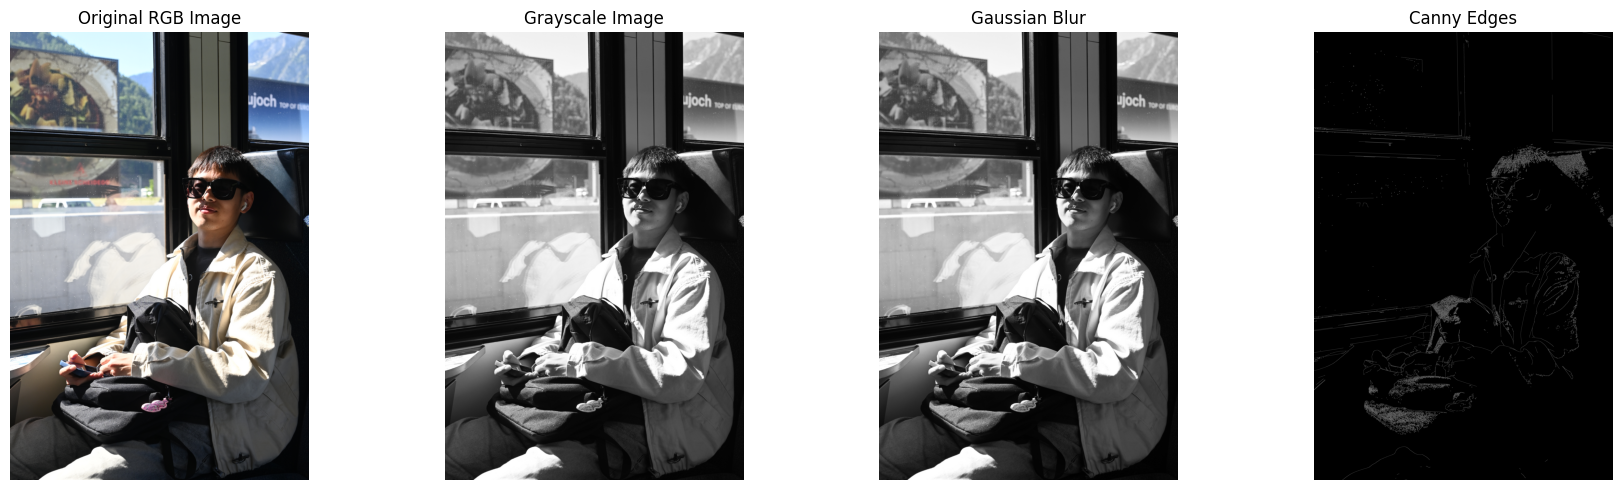

In [7]:
fig, axes = plt.subplots(1, 4, figsize=(18, 5))

axes[0].imshow(image_rgb)
axes[0].set_title("Original RGB Image")
axes[0].axis("off")

axes[1].imshow(gray, cmap="gray")
axes[1].set_title("Grayscale Image")
axes[1].axis("off")

axes[2].imshow(blur, cmap="gray")
axes[2].set_title("Gaussian Blur")
axes[2].axis("off")

axes[3].imshow(edges, cmap="gray")
axes[3].set_title("Canny Edges")
axes[3].axis("off")

plt.tight_layout()
plt.show()

In [8]:
gray_saved = cv2.imwrite(str(gray_output_path), gray)
edges_saved = cv2.imwrite(str(edges_output_path), edges)

if not gray_saved:
    raise IOError(f"Failed to save image: {gray_output_path}")

if not edges_saved:
    raise IOError(f"Failed to save image: {edges_output_path}")

print(f"Saved: {gray_output_path}")
print(f"Saved: {edges_output_path}")

Saved: e:\Internship\Bytedance\face-ai-project\outputs\images\jupyter_gray.jpg
Saved: e:\Internship\Bytedance\face-ai-project\outputs\images\jupyter_edges.jpg


In [9]:
report_lines = [
    "Jupyter Environment and OpenCV Demo Result",
    "=" * 50,
    f"Operating system: {environment_info['Operating system']}",
    f"Python version: {environment_info['Python version']}",
    f"PyTorch version: {environment_info['PyTorch version']}",
    f"CUDA available: {environment_info['CUDA available']}",
    f"CUDA version: {environment_info['CUDA version']}",
    f"GPU name: {environment_info['GPU name']}",
    f"OpenCV version: {environment_info['OpenCV version']}",
    f"NumPy version: {environment_info['NumPy version']}",
    f"Matplotlib version: {environment_info['Matplotlib version']}",
    "",
    f"Input image: {input_path.relative_to(project_root)}",
    f"Input image shape: {image_bgr.shape}",
    f"Input image dtype: {image_bgr.dtype}",
    "",
    "Processing steps:",
    "1. Read the input image",
    "2. Convert BGR image to RGB",
    "3. Convert image to grayscale",
    "4. Apply Gaussian blur",
    "5. Apply Canny edge detection",
    "6. Visualize results with Matplotlib",
    "7. Save processed images",
    "",
    f"Gray output: {gray_output_path.relative_to(project_root)}",
    f"Edges output: {edges_output_path.relative_to(project_root)}",
    "",
    "Result: Successful",
]

report_text = "\n".join(report_lines)

report_output_path.write_text(
    report_text,
    encoding="utf-8",
)

print(report_text)
print(f"\nReport saved to: {report_output_path}")

Jupyter Environment and OpenCV Demo Result
Operating system: Windows-10-10.0.19041-SP0
Python version: 3.10.20
PyTorch version: 2.5.1+cu121
CUDA available: True
CUDA version: 12.1
GPU name: NVIDIA GeForce RTX 2060
OpenCV version: 4.13.0
NumPy version: 2.2.6
Matplotlib version: 3.10.9

Input image: data\samples\test.jpg
Input image shape: (6016, 4016, 3)
Input image dtype: uint8

Processing steps:
1. Read the input image
2. Convert BGR image to RGB
3. Convert image to grayscale
4. Apply Gaussian blur
5. Apply Canny edge detection
6. Visualize results with Matplotlib
7. Save processed images

Gray output: outputs\images\jupyter_gray.jpg
Edges output: outputs\images\jupyter_edges.jpg

Result: Successful

Report saved to: e:\Internship\Bytedance\face-ai-project\outputs\reports\jupyter_demo_result.txt


## Result Summary

The Jupyter Notebook experiment was completed successfully.

The experiment verified:

- Python package imports
- PyTorch installation
- CUDA availability
- GPU device detection
- OpenCV image loading
- NumPy array processing
- Matplotlib image visualization
- Grayscale conversion
- Gaussian blur
- Canny edge detection
- Processed image saving
- Experiment report generation

The notebook confirms that the `face_ai` environment can be used for interactive computer vision experiments.

## Limitations

This notebook only verifies the basic development and image processing workflow.

It does not currently include:

- MMDetection
- Model training
- Face landmark detection
- Face alignment
- Face recognition
- Dataset exploration